# Sesión 5. Diagnóstico, validación cruzada y tuning de hiperparámetros

> **Datasets:**  
> 🏠 `house_prices.csv`: Regresión (predecir `SalePrice`)  
> 🚢 `titanic.csv`: Clasificación (predecir `Survived`)
>
> ¿Cómo sé si mi modelo es bueno o si solo tuve suerte con el split?

---

## Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, cross_val_score,
    KFold, StratifiedKFold,
    learning_curve, validation_curve,
    GridSearchCV, RandomizedSearchCV
)
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    classification_report, ConfusionMatrixDisplay,
    accuracy_score, f1_score, roc_auc_score,
    mean_absolute_error, r2_score
)
from scipy.stats import randint, uniform

VIOLET = '#6C4FF6'
CORAL  = '#FF6B6B'
AMBER  = '#FFB020'
DARK   = '#1B1035'
MUTED  = '#6B6478'
GREEN  = '#2ECC71'

# ── Datasets ──
hp      = pd.read_csv('../data/train.csv')
titanic = pd.read_csv('../data/titanic/train.csv')

# House Prices
X_hp = hp.drop(columns='SalePrice')
y_hp = np.log1p(hp['SalePrice'])
X_hp_tr, X_hp_te, y_hp_tr, y_hp_te = train_test_split(
    X_hp, y_hp, test_size=0.2, random_state=42)

titanic['Sex'] = (titanic['Sex'] == 'female').astype(int)
X_tt = titanic[['Pclass', 'Sex', 'Age', 'SibSp', 'Fare']]
y_tt = titanic['Survived']
X_tt_tr, X_tt_te, y_tt_tr, y_tt_te = train_test_split(
    X_tt, y_tt, test_size=0.2, random_state=42, stratify=y_tt)

print('House Prices  train:', X_hp_tr.shape, '| test:', X_hp_te.shape)
print('Titanic       train:', X_tt_tr.shape, '| test:', X_tt_te.shape)
print()

---
## El problema del split único

Cuando evalúas un modelo con un solo split, tu métrica depende del azar de qué datos cayeron en test.

> Si test tiene casos fáciles, el modelo parece mejor de lo que es.  
> Si test tiene casos difíciles, parece peor.  
> El problema no es el modelo, es el estimador de su rendimiento.

In [ ]:
# Pipeline
pipe_demo = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  DecisionTreeClassifier(max_depth=4, random_state=None))
])

scores_distintos = []
for seed in range(20):
    Xtr, Xte, ytr, yte = train_test_split(
        X_tt, y_tt, test_size=0.2, random_state=seed)
    pipe_demo.fit(Xtr, ytr)
    scores_distintos.append(pipe_demo.score(Xte, yte))

fig, ax = plt.subplots(figsize=(10, 3.5), facecolor='white')
ax.bar(range(20), scores_distintos, color=VIOLET, edgecolor='white',
       linewidth=0.4, alpha=0.85)
ax.axhline(np.mean(scores_distintos), color=AMBER, linewidth=2,
           linestyle='--', label=f'Media = {np.mean(scores_distintos):.3f}')
ax.axhline(max(scores_distintos), color=GREEN, linewidth=1.2,
           linestyle=':', label=f'Máx = {max(scores_distintos):.3f}')
ax.axhline(min(scores_distintos), color=CORAL, linewidth=1.2,
           linestyle=':', label=f'Mín = {min(scores_distintos):.3f}')
ax.set_xlabel('Número de split (random_state=0..19)', fontsize=11)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_title('El mismo modelo: 20 splits distintos, 20 resultados distintos',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0.5, 1.0)
ax.annotate(f'Rango: {max(scores_distintos)-min(scores_distintos):.3f}',
            xy=(0.75, 0.15), xycoords='axes fraction', fontsize=11,
            bbox=dict(boxstyle='round,pad=0.3', fc='#FFF3CD', ec=AMBER))
plt.tight_layout()
plt.show()

print(f'Media:  {np.mean(scores_distintos):.4f}')
print(f'Std:    {np.std(scores_distintos):.4f}')
print(f'Rango:  {max(scores_distintos)-min(scores_distintos):.4f}')
print()
print('Con un solo split podrías reportar el máximo o el mínimo sin saberlo.')

---
## K-Fold: Evaluar en todos los subconjuntos

K-Fold divide el dataset en K partes. En cada iteración usa K-1 para entrenar y 1 para evaluar:

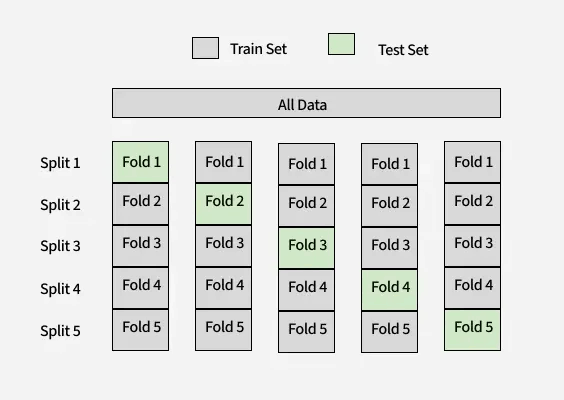

El promedio estima el rendimiento real. La std mide qué tan estable es el modelo.

> K-Fold siempre va dentro de un Pipeline, así el scaler hace `fit_transform`
> en los K-1 folds de train y solo `transform` en el fold de validación.  
> Si escalas fuera del Pipeline, el scaler aprende la distribución del fold de validación, data leakage.

In [ ]:
pipe_kf = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  DecisionTreeClassifier(max_depth=4, random_state=42))
])

kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores_kf = cross_val_score(
    pipe_kf, X_tt_tr, y_tt_tr,
    cv=kf,
    scoring='accuracy'
)

# Split único para comparar
pipe_kf.fit(X_tt_tr, y_tt_tr)
score_unico = pipe_kf.score(X_tt_te, y_tt_te)

print('=== KFold (K=5) ===')
for i, s in enumerate(scores_kf):
    print(f'  Fold {i+1}: {s:.4f}')
print(f'  Media:  {scores_kf.mean():.4f}')
print(f'  Std:    {scores_kf.std():.4f}')
print()
print(f'Split único en test: {score_unico:.4f}')
print()
print('La media de CV es más confiable que cualquier split único.')
print('La std nos dice qué tan estable es el modelo entre distintos subconjuntos.')

---
## StratifiedKFold

Con K-Fold estándar, un fold podría terminar con muy pocos ejemplos de la clase minoritaria.  
`StratifiedKFold` garantiza que cada fold mantiene la misma proporción de clases que el dataset original.

Si tu problema es clasificación, usa siempre `StratifiedKFold`.

In [ ]:
kf_std   = KFold(n_splits=5, shuffle=True, random_state=42)
kf_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

prop_std   = []
prop_strat = []

for (_, te_s), (_, te_st) in zip(
        kf_std.split(X_tt_tr, y_tt_tr),
        kf_strat.split(X_tt_tr, y_tt_tr)):
    prop_std.append(y_tt_tr.iloc[te_s].mean())
    prop_strat.append(y_tt_tr.iloc[te_st].mean())

prop_global = y_tt_tr.mean()

fig, axes = plt.subplots(1, 2, figsize=(10, 4), facecolor='white')

for ax, props, titulo in zip(
        axes,
        [prop_std, prop_strat],
        ['KFold estándar', 'StratifiedKFold']):
    ax.bar(range(1, 6), props, color=VIOLET, edgecolor='white',
           linewidth=0.4, alpha=0.85)
    ax.axhline(prop_global, color=AMBER, linewidth=2, linestyle='--',
               label=f'Proporción global = {prop_global:.2f}')
    ax.set_ylim(0, 0.8)
    ax.set_xlabel('Fold', fontsize=11)
    ax.set_ylabel('Proporción clase positiva (Survived=1)', fontsize=10)
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    std_val = np.std(props)
    ax.annotate(f'Std entre folds: {std_val:.4f}',
                xy=(0.05, 0.88), xycoords='axes fraction', fontsize=10,
                bbox=dict(boxstyle='round,pad=0.3',
                          fc='#EEF2FF' if 'Stratified' in titulo else '#FFF3CD',
                          ec=VIOLET if 'Stratified' in titulo else AMBER))

fig.suptitle('StratifiedKFold mantiene la proporción de clases en cada fold',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## Curvas de aprendizaje

**¿Tienes suficientes datos?** La curva de aprendizaje muestra cómo evolucionan train y test score conforme aumenta el tamaño del dataset.

| Patrón | Diagnóstico |
|--------|-------------|
| Train alto, test bajo, gap grande | Overfitting: El modelo memoriza |
| Train bajo, test bajo, gap pequeño | Underfitting: El modelo es muy simple |
| Train y test convergiendo arriba | Buen ajuste |
| Train y test convergiendo abajo | Necesitas más datos |

In [ ]:
def plot_learning_curve(estimator, X, y, titulo, scoring='accuracy'):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y,
        train_sizes=np.linspace(0.1, 1.0, 10),
        cv=cv, scoring=scoring, n_jobs=-1
    )
    tr_mean = train_scores.mean(axis=1)
    tr_std  = train_scores.std(axis=1)
    te_mean = test_scores.mean(axis=1)
    te_std  = test_scores.std(axis=1)

    fig, ax = plt.subplots(figsize=(9, 4.5), facecolor='white')
    ax.plot(train_sizes, tr_mean, color=VIOLET, linewidth=2,
            marker='o', markersize=5, label='Train')
    ax.fill_between(train_sizes, tr_mean-tr_std, tr_mean+tr_std,
                    alpha=0.12, color=VIOLET)
    ax.plot(train_sizes, te_mean, color=CORAL, linewidth=2,
            marker='s', markersize=5, label='Validación (CV)')
    ax.fill_between(train_sizes, te_mean-te_std, te_mean+te_std,
                    alpha=0.12, color=CORAL)
    gap = tr_mean[-1] - te_mean[-1]
    ax.annotate(f'Gap final: {gap:.3f}',
                xy=(train_sizes[-1], (tr_mean[-1]+te_mean[-1])/2),
                xytext=(-80, 0), textcoords='offset points', fontsize=10,
                arrowprops=dict(arrowstyle='->', color=MUTED),
                bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=MUTED))
    ax.set_xlabel('Tamaño del conjunto de entrenamiento', fontsize=11)
    ax.set_ylabel(scoring, fontsize=11)
    ax.set_title(titulo, fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.show()
    return gap

# Árbol sin restricción dentro de Pipeline
pipe_nomax = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  DecisionTreeClassifier(random_state=42))
])
gap = plot_learning_curve(
    pipe_nomax, X_tt_tr, y_tt_tr,
    'Curva de aprendizaje. Decision Tree sin max_depth.'
)
print(f'Gap = {gap:.3f}. El modelo memoriza train, no generaliza')

In [ ]:
# Árbol con max_depth=4
pipe_max4 = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  DecisionTreeClassifier(max_depth=4, random_state=42))
])
gap = plot_learning_curve(
    pipe_max4, X_tt_tr, y_tt_tr,
    'Curva de aprendizaje. Decision Tree max_depth=4.'
)
print(f'Gap reducido = {gap:.3f}. Regularización reduce el overfitting')

---
## Curvas de validación

**¿Tienes el hiperparámetro correcto?** La curva de validación varía un solo hiperparámetro y muestra su efecto en train y test score.

El punto óptimo es donde el test score es máximo y la brecha con train es mínima.

In [ ]:
param_range = range(1, 16)

# Pipeline dentro de validation_curve
pipe_vc = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  DecisionTreeClassifier(random_state=42))
])

train_scores_vc, test_scores_vc = validation_curve(
    pipe_vc, X_tt_tr, y_tt_tr,
    param_name='model__max_depth',
    param_range=param_range,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy'
)

tr_mean_vc = train_scores_vc.mean(axis=1)
te_mean_vc = test_scores_vc.mean(axis=1)
te_std_vc  = test_scores_vc.std(axis=1)
mejor_depth = list(param_range)[np.argmax(te_mean_vc)]

fig, ax = plt.subplots(figsize=(10, 4.5), facecolor='white')
ax.plot(param_range, tr_mean_vc, color=VIOLET, linewidth=2,
        marker='o', markersize=5, label='Train')
ax.plot(param_range, te_mean_vc, color=CORAL, linewidth=2,
        marker='s', markersize=5, label='Validación (CV)')
ax.fill_between(param_range,
                te_mean_vc - te_std_vc,
                te_mean_vc + te_std_vc,
                alpha=0.12, color=CORAL)
ax.axvline(mejor_depth, color=AMBER, linestyle='--', linewidth=2,
           label=f'Óptimo: max_depth={mejor_depth}')
ax.axvspan(1, 3, alpha=0.05, color=CORAL)
ax.axvspan(mejor_depth+1, 15, alpha=0.05, color=VIOLET)
ax.text(2, ax.get_ylim()[0]+0.02, 'Underfitting', fontsize=9,
        color=CORAL, ha='center')
ax.text(mejor_depth+2.5, ax.get_ylim()[0]+0.02, 'Overfitting', fontsize=9,
        color=VIOLET, ha='center')
ax.set_xlabel('max_depth', fontsize=11)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_title('Curva de validación de max_depth en Decision Tree',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'Mejor max_depth según CV: {mejor_depth}')
print(f'Accuracy en validación:   {te_mean_vc[mejor_depth-1]:.4f} ± {te_std_vc[mejor_depth-1]:.4f}')

---
## GridSearchCV

Prueba todas las combinaciones posibles de hiperparámetros, evaluando cada una con CV interna sobre train.

> El tuning siempre ocurre sobre train con CV interna.  
> Nunca usar test para elegir hiperparámetros, eso es data leakage.

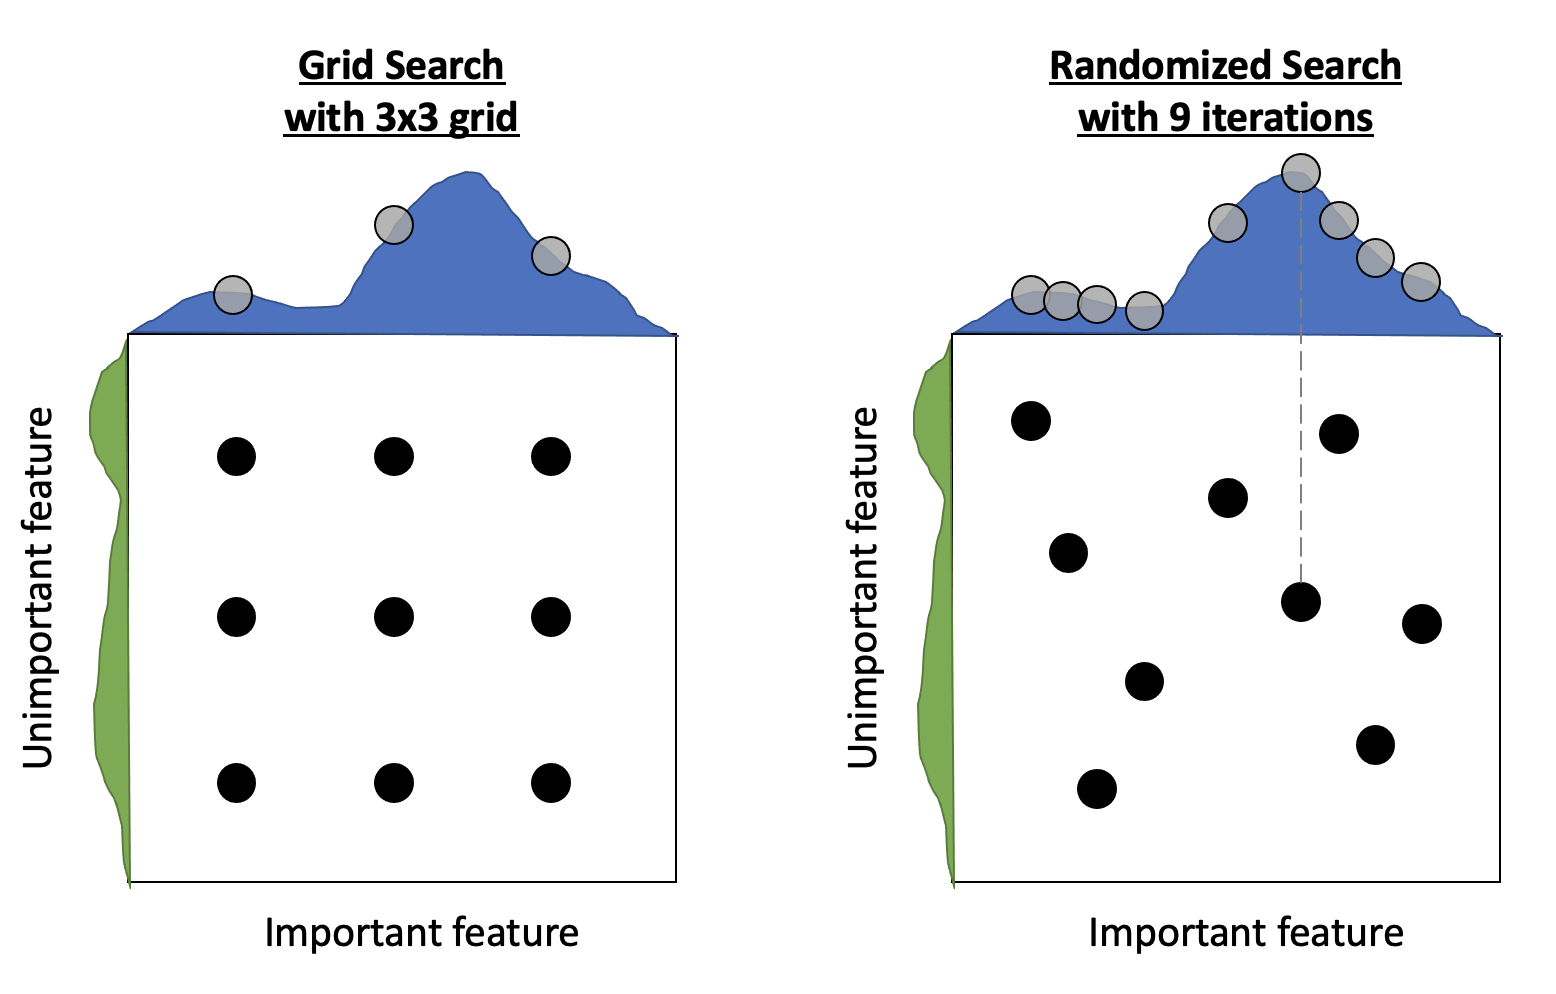

In [ ]:
# Pipeline completo dentro del GridSearch
pipe_gs = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  DecisionTreeClassifier(random_state=42))
])

param_grid = {
    'model__max_depth':        [3, 4, 5, 7, 10, None],
    'model__min_samples_leaf': [1, 5, 10, 20],
    'model__criterion':        ['gini', 'entropy']
}

print(f'Total combinaciones:   {6*4*2}')
print(f'Total entrenamientos:  {6*4*2*5}')

grid_search = GridSearchCV(
    estimator  = pipe_gs,
    param_grid = param_grid,
    cv         = StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring    = 'accuracy',
    n_jobs     = -1,
    refit      = True,
    verbose    = 0
)

grid_search.fit(X_tt_tr, y_tt_tr)

print()
print('=== GridSearchCV ===')
print('Mejores hiperparámetros:', grid_search.best_params_)
print(f'Mejor accuracy en CV:    {grid_search.best_score_:.4f}')

In [ ]:
# Explorar resultados
resultados = pd.DataFrame(grid_search.cv_results_)
top10 = (resultados[['params','mean_test_score','std_test_score','rank_test_score']]
         .sort_values('rank_test_score').head(10).reset_index(drop=True))
print('Top 10 combinaciones:')
print(top10.to_string(index=False))

# Heatmap: max_depth vs min_samples_leaf
pivot = resultados.groupby(
    ['param_model__max_depth','param_model__min_samples_leaf']
)['mean_test_score'].mean().unstack()

fig, ax = plt.subplots(figsize=(8, 4), facecolor='white')
im = ax.imshow(pivot.values, cmap='RdYlGn', aspect='auto',
               vmin=pivot.values.min(), vmax=pivot.values.max())
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, fontsize=10)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([str(x) for x in pivot.index], fontsize=10)
ax.set_xlabel('min_samples_leaf', fontsize=11)
ax.set_ylabel('max_depth', fontsize=11)
ax.set_title('Heatmap de hiperparámetros. Accuracy promedio (criterion promediado).',
             fontsize=12, fontweight='bold')
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax.text(j, i, f'{pivot.values[i,j]:.3f}',
                ha='center', va='center', fontsize=9)
plt.colorbar(im, ax=ax, label='Accuracy')
plt.tight_layout()
plt.show()

---
## RandomizedSearchCV

En lugar de probar todas las combinaciones, muestrea aleatoriamente `n_iter` del espacio.  
Puede usar distribuciones continuas, no solo listas discretas.

### ¿Por qué es más eficiente que GridSearch?

Si solo un hiperparámetro importa, GridSearch desperdicia evaluaciones variando los irrelevantes.  
RandomSearch explora más valores del parámetro que importa con el mismo presupuesto.

> **Bergstra & Bengio (2012):** La búsqueda aleatoria es más eficiente cuando el espacio tiene
> **dimensiones irrelevantes** y en la mayoría de modelos, pocos hiperparámetros concentran el impacto.

In [ ]:
pipe_rs = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  RandomForestClassifier(random_state=42))
])

param_dist = {
    'model__n_estimators':     randint(50, 500),
    'model__max_depth':        randint(3, 20),
    'model__min_samples_leaf': randint(1, 50),
    'model__max_features':     uniform(0.1, 0.9),
}

random_search = RandomizedSearchCV(
    estimator           = pipe_rs,
    param_distributions = param_dist,
    n_iter              = 60,
    cv                  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring             = 'accuracy',
    n_jobs              = -1,
    random_state        = 42,
    refit               = True,
    verbose             = 0
)

random_search.fit(X_tt_tr, y_tt_tr)

print('=== RandomizedSearchCV (60 iteraciones × 5 folds = 300 entrenamientos) ===')
print('Mejores hiperparámetros:', random_search.best_params_)
print(f'Mejor accuracy en CV:    {random_search.best_score_:.4f}')

In [ ]:
# Visualización del espacio explorado
res_rand = pd.DataFrame(random_search.cv_results_)

fig, axes = plt.subplots(1, 3, figsize=(13, 4), facecolor='white')
params_plot = [
    ('param_model__n_estimators', 'n_estimators'),
    ('param_model__max_depth',    'max_depth'),
    ('param_model__max_features', 'max_features'),
]
for ax, (col, label) in zip(axes, params_plot):
    sc = ax.scatter(
        res_rand[col].astype(float),
        res_rand['mean_test_score'],
        c=res_rand['mean_test_score'],
        cmap='RdYlGn', alpha=0.7, s=40,
        vmin=res_rand['mean_test_score'].min(),
        vmax=res_rand['mean_test_score'].max()
    )
    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel('Accuracy' if label=='n_estimators' else '', fontsize=11)
    ax.set_title(f'Accuracy vs {label}', fontsize=11, fontweight='bold')

fig.suptitle('RandomizedSearchCV. Espacio explorado.',
             fontsize=13, fontweight='bold', y=1.01)
plt.colorbar(sc, ax=axes[-1], label='Accuracy')
plt.tight_layout()
plt.show()

---
## GridSearch vs RandomizedSearch

In [ ]:
np.random.seed(42)
n_eval = 9

grid_x = np.repeat([0.2, 0.5, 0.8], 3)
grid_y = np.tile([0.2, 0.5, 0.8], 3)
rand_x = np.random.uniform(0, 1, n_eval)
rand_y = np.random.uniform(0, 1, n_eval)

def perf(x): return np.sin(np.pi * x) * 0.5 + 0.5
x_curve = np.linspace(0, 1, 200)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), facecolor='white')

for ax, xs, ys, titulo, color in zip(
        axes,
        [grid_x, rand_x], [grid_y, rand_y],
        ['Grid Search (3×3 = 9 evaluaciones)', 'RandomizedSearch (9 iteraciones)'],
        [VIOLET, CORAL]):

    ax.scatter(xs, ys, s=80, color=DARK, zorder=5)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel('Parámetro importante', fontsize=11)
    ax.set_ylabel('Parámetro irrelevante', fontsize=11)
    ax.set_title(titulo, fontsize=12, fontweight='bold')

    ax_top = ax.inset_axes([0, 1.05, 1, 0.25])
    ax_top.fill_between(x_curve, perf(x_curve), alpha=0.3, color=color)
    ax_top.plot(x_curve, perf(x_curve), color=color, linewidth=1.5)
    ax_top.scatter(xs, perf(xs), s=60, color=DARK, zorder=5)
    ax_top.set_xlim(0, 1); ax_top.set_ylim(0, 1.1); ax_top.axis('off')

    ax_left = ax.inset_axes([-0.30, 0, 0.25, 1])
    ax_left.fill_betweenx([0,1], 0, 0.3, alpha=0.2, color=GREEN)
    ax_left.scatter([0.15]*len(ys), ys, s=60, color=DARK, zorder=5)
    ax_left.set_xlim(0, 0.5); ax_left.set_ylim(0, 1); ax_left.axis('off')

    n_unique = len(np.unique(xs.round(4)))
    ax.annotate(f'{n_unique} valores únicos en eje importante',
                xy=(0.05, 0.05), xycoords='axes fraction', fontsize=10,
                bbox=dict(boxstyle='round,pad=0.3', fc='#EEF2FF', ec=color))

fig.suptitle('GridSearch vs RandomSearch',
             fontsize=12, fontweight='bold', y=1.15)
plt.tight_layout()
plt.show()

---
## Evaluación final

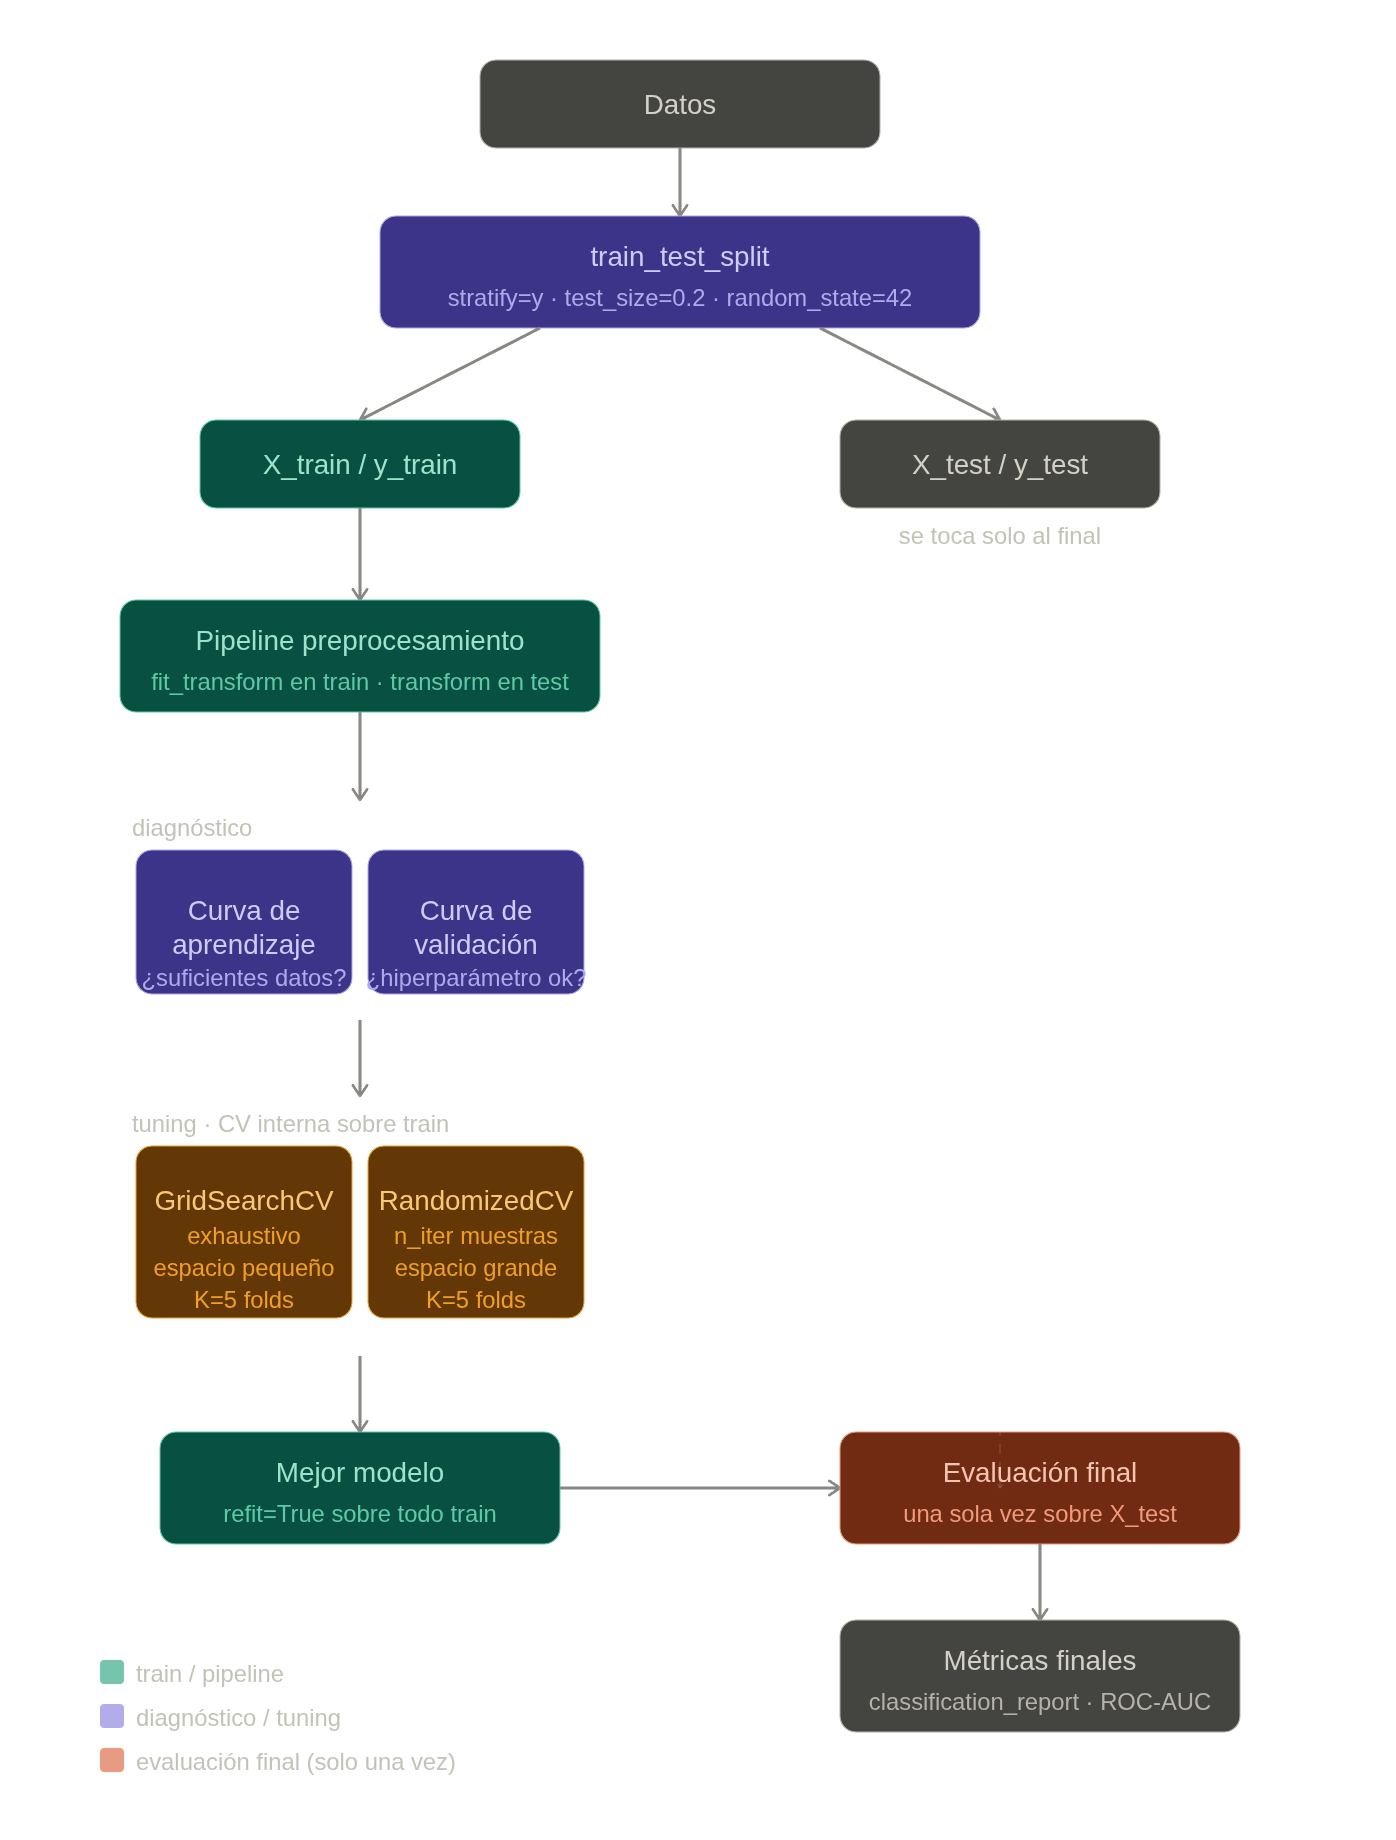

In [ ]:
mejor_modelo = grid_search.best_estimator_

y_pred = mejor_modelo.predict(X_tt_te)
y_prob = mejor_modelo.predict_proba(X_tt_te)[:, 1]

acc = accuracy_score(y_tt_te, y_pred)
f1  = f1_score(y_tt_te, y_pred)
auc = roc_auc_score(y_tt_te, y_prob)

print('=== EVALUACIÓN FINAL ===')
print()
print(classification_report(y_tt_te, y_pred,
                             target_names=['No sobrevivió','Sobrevivió']))
print(f'ROC-AUC: {auc:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), facecolor='white')

ConfusionMatrixDisplay.from_predictions(
    y_tt_te, y_pred,
    display_labels=['No sobrevivió','Sobrevivió'],
    ax=axes[0], colorbar=False, cmap='Purples'
)
axes[0].set_title('Matriz de confusión', fontsize=12, fontweight='bold')

# Comparativa baseline / sin tuning / con tuning
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_tt_tr, y_tt_tr)
acc_base = accuracy_score(y_tt_te, dummy.predict(X_tt_te))

pipe_notuning = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  DecisionTreeClassifier(max_depth=4, random_state=42))
])
pipe_notuning.fit(X_tt_tr, y_tt_tr)
acc_notuning = accuracy_score(y_tt_te, pipe_notuning.predict(X_tt_te))

modelos = ['Baseline\n(mayoría)', 'Decision Tree\n(sin tuning)', 'Decision Tree\n(GridSearch)']
accs    = [acc_base, acc_notuning, acc]
colores = [MUTED, VIOLET, AMBER]

bars = axes[1].bar(modelos, accs, color=colores, edgecolor='white', linewidth=0.5)
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel('Accuracy', fontsize=11)
axes[1].set_title('Impacto del tuning', fontsize=12, fontweight='bold')
for bar, val in zip(bars, accs):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.02,
                 f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')

fig.suptitle('Evaluación final — Decision Tree tuneado con GridSearchCV',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## Bonus: RandomizedSearch sobre regresión

El mismo flujo aplica para regresión, solo cambia la métrica (`r2`, `neg_mean_absolute_error`).

In [ ]:
pipe_reg = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  RandomForestRegressor(random_state=42))
])

param_dist_reg = {
    'model__n_estimators':     randint(50, 400),
    'model__max_depth':        randint(3, 15),
    'model__min_samples_leaf': randint(1, 30),
    'model__max_features':     uniform(0.3, 0.7),
}

rs_reg = RandomizedSearchCV(
    estimator           = pipe_reg,
    param_distributions = param_dist_reg,
    n_iter              = 50,
    cv                  = KFold(n_splits=5, shuffle=True, random_state=42),
    scoring             = 'r2',
    n_jobs              = -1,
    random_state        = 42,
    refit               = True,
    verbose             = 0
)

# Seleccionar solo columnas numéricas
cols_num_hp = X_hp_tr.select_dtypes(include='number').columns.tolist()

rs_reg.fit(X_hp_tr[cols_num_hp], y_hp_tr)

y_pred_reg = rs_reg.best_estimator_.predict(X_hp_te[cols_num_hp])
r2_final   = r2_score(y_hp_te, y_pred_reg)
mae_final  = mean_absolute_error(y_hp_te, y_pred_reg)

print('=== RandomForest Regressor ===')
print('Mejores hiperparámetros:', rs_reg.best_params_)
print(f'R² en CV:    {rs_reg.best_score_:.4f}')
print(f'R² en test:  {r2_final:.4f}')
print(f'MAE en test: {mae_final:.4f}')

fig, ax = plt.subplots(figsize=(7, 5), facecolor='white')
ax.scatter(y_hp_te, y_pred_reg, alpha=0.4, color=VIOLET,
           edgecolors='white', linewidth=0.3, s=30)
lims = [min(y_hp_te.min(), y_pred_reg.min()),
        max(y_hp_te.max(), y_pred_reg.max())]
ax.plot(lims, lims, '--', color=AMBER, linewidth=1.5, label='Predicción perfecta')
ax.set_xlabel('log1p(SalePrice) real', fontsize=11)
ax.set_ylabel('Predicho', fontsize=11)
ax.set_title('RandomForest tuneado', fontsize=13, fontweight='bold')
ax.annotate(f'R² = {r2_final:.3f}', xy=(0.05, 0.88),
            xycoords='axes fraction', fontsize=12,
            bbox=dict(boxstyle='round,pad=0.3', fc='#EEF2FF', ec=VIOLET))
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

---
## Resumen del flujo completo

| Paso | Herramienta | Por qué |
|------|-------------|----------|
| Split inicial | `train_test_split(stratify=y)` | Test no visto hasta el final |
| Estimación robusta | `cross_val_score` con `StratifiedKFold` dentro de Pipeline | Más estable que un split único; sin leakage del scaler |
| ¿Suficientes datos? | `learning_curve` | Detecta underfitting por falta de datos |
| ¿Hiperparámetro ok? | `validation_curve` | Encuentra el rango óptimo antes de buscar |
| Búsqueda: espacio pequeño | `GridSearchCV` | Garantiza el óptimo de la grilla |
| Búsqueda: espacio grande | `RandomizedSearchCV` | Más eficiente con muchos hiperparámetros |
| Evaluación definitiva | `predict` sobre test | Una sola vez — nunca vuelvas a tunear |

---

**Referencias:**
- Bergstra, J., & Bengio, Y. (2012). Random search for hyper-parameter optimization. *JMLR, 13*, 281–305.
- scikit-learn developers. (2024). *Cross-validation: evaluating estimator performance*. https://scikit-learn.org/stable/modules/cross_validation.html
- Géron, A. (2019). *Hands-on machine learning* (2nd ed.). O'Reilly. Cap. 2.
